In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
#%matplotlib notebook
#%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
import json
from typing import Dict, Optional, Tuple, List
import random

class Parameter:
    def __init__(self, name: str, value: float, range: Optional[Tuple[float, float]] = None, distribution: Optional[str] = None):
        """
        Base class for a parameter.

        :param name: Name of the parameter
        :param value: Value of the parameter
        :param range: Range of the parameter (optional)
        :param distribution: Distribution of the parameter (optional)
        """
        self.name = name
        self.value = value
        self.range = range
        self.distribution = distribution

    def to_dict(self) -> Dict:
        """Convert the parameter to a dictionary."""
        return {
            "name": self.name,
            "value": self.value,
            "range": self.range,
            "distribution": self.distribution
        }

    @classmethod
    def from_dict(cls, data: Dict):
        """Create a Parameter instance from a dictionary."""
        return cls(
            name=data["name"],
            value=data["value"],
            range=data.get("range"),
            distribution=data.get("distribution")
        )

    def to_json(self) -> str:
        """Serialize the parameter to a JSON string."""
        return json.dumps(self.to_dict(), indent=4)

    @classmethod
    def from_json(cls, json_str: str):
        """Create a Parameter instance from a JSON string."""
        data = json.loads(json_str)
        return cls.from_dict(data)

    def cast_to(self, target_class):
        """
        Cast the parameter to a different class.

        :param target_class: Target class to cast to (Constant, Variable, DistributedVariable)
        """
        return target_class.from_dict(self.to_dict())

    def sample_values(self, n: int) -> List[float]:
        """
        Generate n sampled values. To be implemented by subclasses if needed.
        """
        return [self.value for _ in range(n)]

class Constant(Parameter):
    def __init__(self, name: str, value: float, range: Optional[Tuple[float, float]] = None, distribution: Optional[str] = None):
        super().__init__(name, value, range, distribution)

    def sample_value(self) -> float:
        """
        Always return the constant value.
        """
        return self.value

    def sample_values(self, n: int) -> List[float]:
        """
        Return n constant values.
        """
        return [self.value for _ in range(n)]

class Variable(Parameter):
    def __init__(self, name: str, value: float, range: Tuple[float, float], distribution: Optional[str] = None):
        super().__init__(name, value, range, distribution)

    def sample_values(self, n: int) -> List[float]:
        """
        Return n sampled values within the range. Subclasses can override.
        """
        return [self.value for _ in range(n)]

class DistributedVariable(Variable):
    def __init__(self, name: str, value: float, range: Tuple[float, float], distribution: str, **distribution_params):
        super().__init__(name, value, range, distribution)
        self.distribution_params = distribution_params

    def generate_value(self) -> float:
        """
        Generate a value based on the defined distribution within the range.
        """
        min_val, max_val = self.range

        if self.distribution == "normal":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            std_dev = self.distribution_params.get("std_dev", (max_val - min_val) / 6)
            return max(min(random.gauss(mean, std_dev), max_val), min_val)

        elif self.distribution == "truncated_gauss":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            std_dev = self.distribution_params.get("std_dev", (max_val - min_val) / 6)
            value = random.gauss(mean, std_dev)
            while not (min_val <= value <= max_val):
                value = random.gauss(mean, std_dev)
            return value

        elif self.distribution == "weibull":
            scale = self.distribution_params.get("scale", (max_val - min_val) / 2)
            shape = self.distribution_params.get("shape", 1.5)
            return max(min(min_val + random.weibullvariate(scale, shape), max_val), min_val)

        elif self.distribution == "uniform":
            return random.uniform(min_val, max_val)

        elif self.distribution == "exponential":
            rate = self.distribution_params.get("rate", 1.0)
            return max(min_val, min(random.expovariate(rate), max_val))

        elif self.distribution == "lognormal":
            mean = self.distribution_params.get("mean", (min_val + max_val) / 2)
            sigma = self.distribution_params.get("sigma", (max_val - min_val) / 6)
            return max(min_val, min(random.lognormvariate(mean, sigma), max_val))

        elif self.distribution == "beta":
            alpha = self.distribution_params.get("alpha", 2.0)
            beta = self.distribution_params.get("beta", 5.0)
            return min_val + (random.betavariate(alpha, beta) * (max_val - min_val))

        elif self.distribution == "gamma":
            shape = self.distribution_params.get("shape", 2.0)
            scale = self.distribution_params.get("scale", 1.0)
            return max(min_val, min(random.gammavariate(shape, scale), max_val))

        elif self.distribution == "cauchy":
            location = self.distribution_params.get("location", (min_val + max_val) / 2)
            scale = self.distribution_params.get("scale", (max_val - min_val) / 4)
            value = random.uniform(location - scale, location + scale)
            return max(min_val, min(value, max_val))

        else:
            raise ValueError(f"Unsupported distribution: {self.distribution}")

    def sample_value(self) -> float:
        """
        Sample and update the value based on the defined distribution.
        """
        self.value = self.generate_value()
        return self.value

    def sample_values(self, n: int) -> List[float]:
        """
        Generate n sampled values based on the defined distribution.
        """
        return [self.generate_value() for _ in range(n)]

# Beispiel: Parameter erstellen und als JSON speichern
const_param = Constant(name="constant_param", value=10.0)
print(const_param.to_json())

var_param = Variable(name="variable_param", value=5.0, range=(0.0, 10.0))
print(var_param.to_json())

dist_param = DistributedVariable(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="truncated_gauss",
    mean=5.0,
    std_dev=1.0
)
print(dist_param.to_json())

# Cast Beispiele
casted_to_variable = const_param.cast_to(Variable)
print(casted_to_variable.to_dict())

casted_to_distributed = var_param.cast_to(DistributedVariable)
print(casted_to_distributed.to_dict())

casted_back_to_constant = casted_to_distributed.cast_to(Constant)
print(casted_back_to_constant.to_dict())

# JSON-Import
loaded_param = DistributedVariable.from_json(dist_param.to_json())
print(loaded_param.to_dict())

# Sampling eines neuen Wertes
sampled_value = loaded_param.sample_value()
print(f"Sampled value: {sampled_value}")

# Sampling von mehreren Werten
sampled_values = loaded_param.sample_values(10)
print(f"Sampled values: {sampled_values}")


{
    "name": "constant_param",
    "value": 10.0,
    "range": null,
    "distribution": null
}
{
    "name": "variable_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "distribution": null
}
{
    "name": "distributed_param",
    "value": 5.0,
    "range": [
        0.0,
        10.0
    ],
    "distribution": "truncated_gauss"
}
{'name': 'constant_param', 'value': 10.0, 'range': None, 'distribution': None}
{'name': 'variable_param', 'value': 5.0, 'range': (0.0, 10.0), 'distribution': None}
{'name': 'variable_param', 'value': 5.0, 'range': (0.0, 10.0), 'distribution': None}
{'name': 'distributed_param', 'value': 5.0, 'range': [0.0, 10.0], 'distribution': 'truncated_gauss'}
Sampled value: 7.5179460383539904
Sampled values: [4.234834248175952, 3.768890366960978, 4.09509865590473, 1.2416326682924117, 5.016522013028081, 5.239312082854964, 6.3337517549051885, 4.758152028640645, 5.64789584411114, 7.027871889865269]


In [17]:
casted_to_distributed = var_param.cast_to(DistributedVariable)
print(casted_to_distributed.to_dict())

{'name': 'variable_param', 'value': 5.0, 'range': (0.0, 10.0), 'distribution': None}


In [18]:
const_param.sample_values(10)

[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

In [19]:
var_param.sample_values(10)

[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]

In [20]:
dist_param.sample_values(10)

[5.004477640031063,
 2.5691870536077386,
 5.746115660574156,
 6.280450842205884,
 3.13401394026298,
 4.212379045513448,
 4.8080826565688835,
 7.259178205195063,
 6.409901897354052,
 3.9053639089114287]

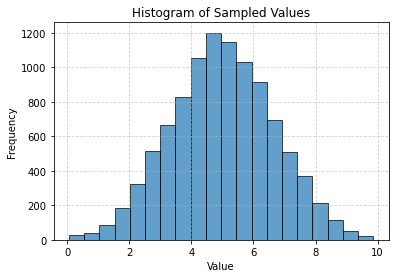

In [21]:

# Plot als Histogramm
dist_param = DistributedVariable(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="truncated_gauss"
)
sampled_values = dist_param.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


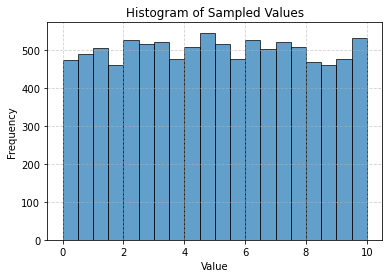

In [22]:

# Plot als Histogramm
dist_param = DistributedVariable(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="uniform"
)
sampled_values = dist_param.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)


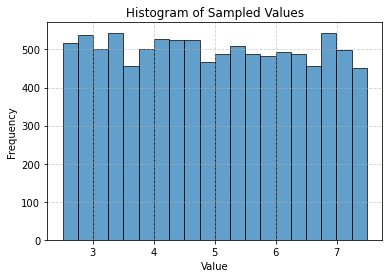

In [23]:


# Plot als Histogramm
dist_param = DistributedVariable(
    name="distributed_param",
    value=5.0,
    range=(0.0, 10.0),
    distribution="cauchy"
)
sampled_values = dist_param.sample_values(10000)
plt.hist(sampled_values, bins=20, edgecolor='black', alpha=0.7)
plt.title('Histogram of Sampled Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)